In [ ]:
import torch
import torch.nn as nn
# Input data
x = torch.tensor([[1.0], [2.0], [3.0]])
y = torch.tensor([[2.0], [4.0], [6.0]])
# Define model
model = nn.Linear(1, 1)
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# Before training
print("Before training:")
print("Weight:", model.weight.item())
print("Bias:", model.bias.item())
print("Predictions:")
print(model(x))
# Training loop
for epoch in range(1000):
    # Forward pass
    y_pred = model(x)
    # Compute loss
    loss = criterion(y_pred, y)
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}")
# After training
print("\nAfter training:")
print("Weight:", model.weight.item())
print("Bias:", model.bias.item())

Before training:
Weight: 0.25555098056793213
Bias: 0.8924815654754639
Predictions:
tensor([[1.1480],
        [1.4036],
        [1.6591]], grad_fn=<AddmmBackward0>)
Epoch [100/1000], Loss: 0.1723
Epoch [200/1000], Loss: 0.1065
Epoch [300/1000], Loss: 0.0658
Epoch [400/1000], Loss: 0.0407
Epoch [500/1000], Loss: 0.0251
Epoch [600/1000], Loss: 0.0155
Epoch [700/1000], Loss: 0.0096
Epoch [800/1000], Loss: 0.0059
Epoch [900/1000], Loss: 0.0037
Epoch [1000/1000], Loss: 0.0023

After training:
Weight: 1.94487726688385
Bias: 0.12530678510665894


In [ ]:
# Final predictions
print("Final predictions:")
print(model(x))
# Test on new value
x_test = torch.tensor([[4.0]])
y_test = model(x_test)
print("Prediction for x = 4.0:")
print(y_test.item())

Final predictions:
tensor([[2.0702],
        [4.0151],
        [5.9599]], grad_fn=<AddmmBackward0>)
Prediction for x = 4.0:
7.904815673828125


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ----------------------------
# 1. Load Dataset
# ----------------------------
iris = load_iris()
X = iris.data # features
y = iris.target # labels (0,1,2)
# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# ----------------------------
# 3. Feature Scaling
# ----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 4. Convert to Tensors
# ----------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
# ----------------------------
# 5. Define Model
# ----------------------------
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(4, 3) # 4 features → 3 classes
    def forward(self, x):
        return self.linear(x)
model = LogisticRegressionModel()
# ----------------------------
# 6. Loss & Optimizer
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
# ----------------------------
# 7. Training Loop
# ----------------------------
epochs = 200
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train)
    # Loss
    loss = criterion(outputs, y_train)
    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Print loss
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [20/200], Loss: 0.8841
Epoch [40/200], Loss: 0.8091
Epoch [60/200], Loss: 0.7497
Epoch [80/200], Loss: 0.7020
Epoch [100/200], Loss: 0.6630
Epoch [120/200], Loss: 0.6305
Epoch [140/200], Loss: 0.6032
Epoch [160/200], Loss: 0.5798
Epoch [180/200], Loss: 0.5596
Epoch [200/200], Loss: 0.5419


In [ ]:
# ----------------------------
# 8. Evaluation
# ----------------------------
with torch.no_grad():
 outputs = model(X_test)
 _, predicted = torch.max(outputs, 1)
 total = y_test.size(0)
 correct = (predicted == y_test).sum().item()
 print("\nAccuracy:", 100 * correct / total)
# ----------------------------
# 9. Sample Prediction
# ----------------------------
sample = X_test[0].unsqueeze(0)
pred = model(sample)
_, predicted_class = torch.max(pred, 1)
print("\nSample Prediction:", predicted_class.item())
print("Actual Label:", y_test[0].item())


Accuracy: 86.66666666666667

Sample Prediction: 2
Actual Label: 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ----------------------------
# 1. Generate Moon Dataset
# ----------------------------
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ----------------------------
# 1. Generate Moon Dataset
# ----------------------------
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [ ]:
# 3. Feature Scaling (skipped as make_moons already has noise, and StandardScaler might distort the moons)
# 4. Convert to Tensors
X_train_moon = torch.tensor(X_train, dtype=torch.float32)
X_test_moon = torch.tensor(X_test, dtype=torch.float32)
y_train_moon = torch.tensor(y_train, dtype=torch.long)
y_test_moon = torch.tensor(y_test, dtype=torch.long)

# 5. Define Model for Moon Dataset (2 input features, 2 classes)
class MoonBinaryClassifier(nn.Module):
    def __init__(self):
        super(MoonBinaryClassifier, self).__init__()
        self.linear = nn.Linear(2, 2) # 2 features -> 2 classes

    def forward(self, x):
        return self.linear(x)

moon_model = MoonBinaryClassifier()

# 6. Loss & Optimizer
criterion_moon = nn.CrossEntropyLoss()
optimizer_moon = optim.SGD(moon_model.parameters(), lr=0.05)

# 7. Training Loop for Moon Model
epochs_moon = 500
for epoch in range(epochs_moon):
    # Forward pass
    outputs_moon = moon_model(X_train_moon)
    # Loss
    loss_moon = criterion_moon(outputs_moon, y_train_moon)
    # Backprop
    optimizer_moon.zero_grad()
    loss_moon.backward()
    optimizer_moon.step()

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs_moon}], Loss: {loss_moon.item():.4f}")

# Evaluation (Optional, but good practice)
with torch.no_grad():
    outputs_moon_test = moon_model(X_test_moon)
    _, predicted_moon = torch.max(outputs_moon_test, 1)
    total_moon = y_test_moon.size(0)
    correct_moon = (predicted_moon == y_test_moon).sum().item()
    print(f"\nMoon Model Accuracy: {100 * correct_moon / total_moon:.2f}%")

Epoch [100/500], Loss: 0.4308
Epoch [200/500], Loss: 0.3569
Epoch [300/500], Loss: 0.3292
Epoch [400/500], Loss: 0.3142
Epoch [500/500], Loss: 0.3048

Moon Model Accuracy: 86.00%


In [ ]:
# After training the moon_model, we can now use it to plot the decision boundary.
# The plot_decision_boundary function is defined in a subsequent cell (YNEHO8vAf0t0).
# We just need to make sure to call it with the correct model and data.
# The original call in YNEHO8vAf0t0 used 'model' (Iris model), which caused the error.
# Now, we will use 'moon_model' and the Moon dataset's X_test and y_test.

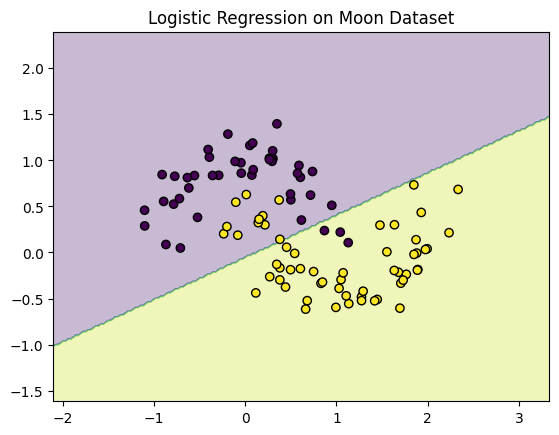

In [ ]:
#9. Plot Decision Boundary
def plot_decision_boundary(model, X, y):
    X_np = X # X is already a numpy array, no need for .numpy()
    y_np = y # y is already a numpy array, no need for .numpy()
    x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
    y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    with torch.no_grad():
        preds = model(grid_tensor)
        _, preds = torch.max(preds, 1)
        Z = preds.numpy().reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, edgecolors='k')
    plt.title("Logistic Regression on Moon Dataset")
    plt.show()

# Call the function with the newly trained moon_model and Moon test data
plot_decision_boundary(moon_model, X_test_moon, y_test_moon)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

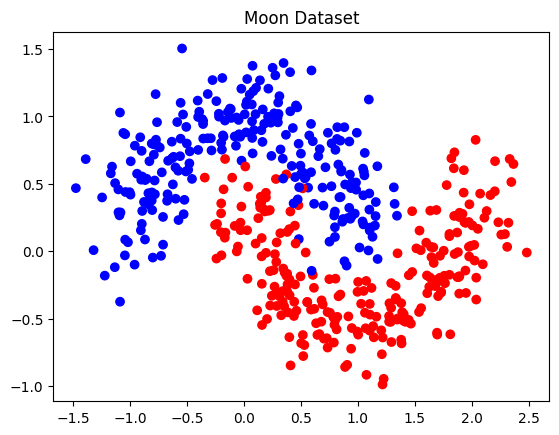

In [ ]:
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title("Moon Dataset")
plt.show()

In [ ]:
model_linear = LogisticRegression()
model_linear.fit(X, y)

LogisticRegression()

In [ ]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
    plt.title(title)
    plt.show()

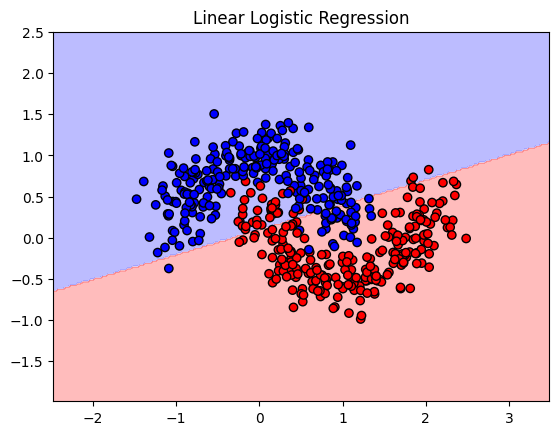

In [ ]:
plot_decision_boundary(model_linear, X, y, "Linear Logistic Regression")

In [ ]:
model_poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("logreg", LogisticRegression(max_iter=10000))
])

model_poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("logreg", LogisticRegression(max_iter=10000))
])

model_poly2.fit(X, y)
model_poly3.fit(X, y)

Pipeline(steps=[('poly', PolynomialFeatures(degree=3)),
                ('logreg', LogisticRegression(max_iter=10000))])

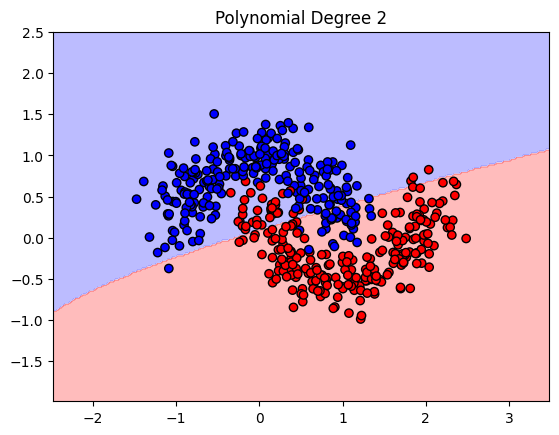

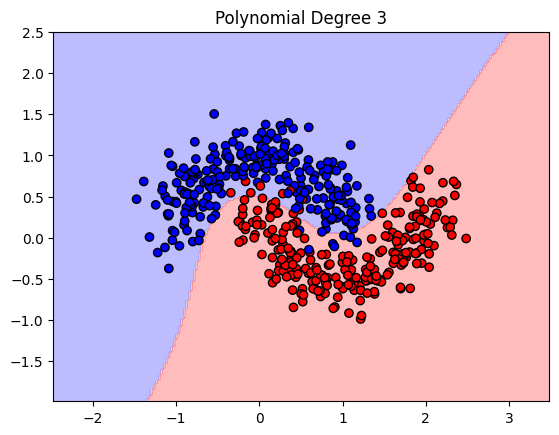

In [ ]:
plot_decision_boundary(model_poly2, X, y, "Polynomial Degree 2")
plot_decision_boundary(model_poly3, X, y, "Polynomial Degree 3")

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9737
Precision : 0.9722
Recall    : 0.9859
F1 Score  : 0.9790
